In [63]:
import pandas as pd
import pyxdf
import numpy as np
import mne
import os

In [64]:
"""
In this notebook, we preprocess and ICA the raw EEG. We then epoch them around sonication time (-2 to 7 seconds) and compute the time dependent PSD. 
"""

'\nIn this notebook, we preprocess and ICA the raw EEG. We then epoch them around sonication time (-2 to 7 seconds) and compute the time dependent PSD. \n'

In [65]:
from pathlib import Path
xdf_path = Path(r"C:\Users\jshin\OW_closedloopLIFU\xdf_data\sub-dave_run_2\ses-1\eeg\sub-dave_run_2_ses-1_task-dave_run_2_run-001_eeg.xdf")
data, header = pyxdf.load_xdf(str(xdf_path))
for i, stream in enumerate(data):
    print(f"Stream {i}: {stream['info']['name'][0]}")

Stream 0: EEG_LIFU_events
Stream 1: PsychoPy_numeric
Stream 2: EEG_gpype
Stream 3: PsychoPyMarkers


In [66]:
EEG_LIFU_events = data[0]

# Create DataFrame from time_series
markers = pd.DataFrame(EEG_LIFU_events['time_series'])

# Rename the first column to 'markers'
markers.rename(columns={0: 'markers'}, inplace=True)

# Add timestamp column
markers['Timestamp'] = EEG_LIFU_events['time_stamps']

# Move Timestamp to be the first column after the index
cols = ['Timestamp'] + [col for col in markers.columns if col != 'Timestamp']
markers = markers[cols]
markers

,Timestamp,markers
0,2.811650e+06,collecting_baseline
1,2.811650e+06,collecting_baseline
2,2.811650e+06,collecting_baseline
3,2.811650e+06,collecting_baseline
4,2.811650e+06,collecting_baseline
...,...,...
113,2.811808e+06,LIFU_OFF
114,2.811831e+06,LIFU_ON
115,2.811836e+06,LIFU_OFF
116,2.811846e+06,LIFU_ON


In [67]:
trial_ts = markers[markers['markers']=='LIFU_ON']['Timestamp']
trial_ts

108    2.811706e+06
110    2.811718e+06
112    2.811803e+06
114    2.811831e+06
116    2.811846e+06
Name: Timestamp, dtype: float64

In [68]:
stream = data[2]
df= []
df = pd.DataFrame(stream['time_series'])
df = df.rename(columns={i: f"Ch{i}" for i in range(df.shape[1])})

# Add timestamp column
df['Timestamp'] = stream['time_stamps']

# Move Timestamp to be the first column after the index
cols = ['Timestamp'] + [col for col in df.columns if col != 'Timestamp']
df = df[cols]
eeg_raw = df[['Ch0', 'Ch1', 'Ch2', 'Ch3', 'Ch4', 'Ch5', 'Ch6', 'Ch12','Timestamp']]
eeg_raw

,Ch0,Ch1,Ch2,Ch3,Ch4,Ch5,Ch6,Ch12,Timestamp
0,-5197.716309,-9999.109375,-3748.226562,3159.284668,-2866.387939,7112.789062,-13532.520508,508.523041,2.811650e+06
1,-4532.313965,-9376.432617,-3339.839355,3736.305420,-2353.596924,7398.152344,-13149.596680,510.835693,2.811650e+06
2,-4534.149902,-9527.708008,-3229.475342,3741.765137,-2398.395752,7449.556152,-13214.398438,510.931061,2.811650e+06
3,-5197.454590,-10201.382812,-3630.185059,3173.923828,-2947.998047,7166.529785,-13616.466797,511.503265,2.811650e+06
4,-5281.139160,-10083.653320,-3786.850342,3092.265137,-2927.542236,7091.618652,-13583.065430,513.339172,2.811650e+06
...,...,...,...,...,...,...,...,...,...
66755,-4525.447754,-9560.348633,-5047.893555,2023.721069,-2443.433105,6835.056152,-14929.820312,513.839722,2.811917e+06
66756,-4568.506348,-9814.859375,-5031.729004,1994.204712,-2664.828857,6802.964844,-15067.554688,514.531128,2.811917e+06
66757,-4709.673340,-9645.843750,-5200.076660,1884.579834,-2535.748779,6772.780273,-14980.723633,513.005249,2.811917e+06
66758,-4677.010254,-9429.646484,-5202.269531,1897.573608,-2361.298096,6789.827148,-14884.854492,513.076843,2.811917e+06


Creating RawArray with float64 data, n_channels=7, n_times=66760


    Range : 0 ... 66759 =      0.000 ...   267.036 secs


Ready.


Filtering raw data in 1 contiguous segment


Setting up band-pass filter from 1 - 40 Hz


...

Applying average reference.


Applying a custom ('EEG',) reference.


Fitting ICA to data using 7 channels (please be patient, this may take a while)


Selecting by explained variance: 6 components


Fitting ICA took 0.3s.


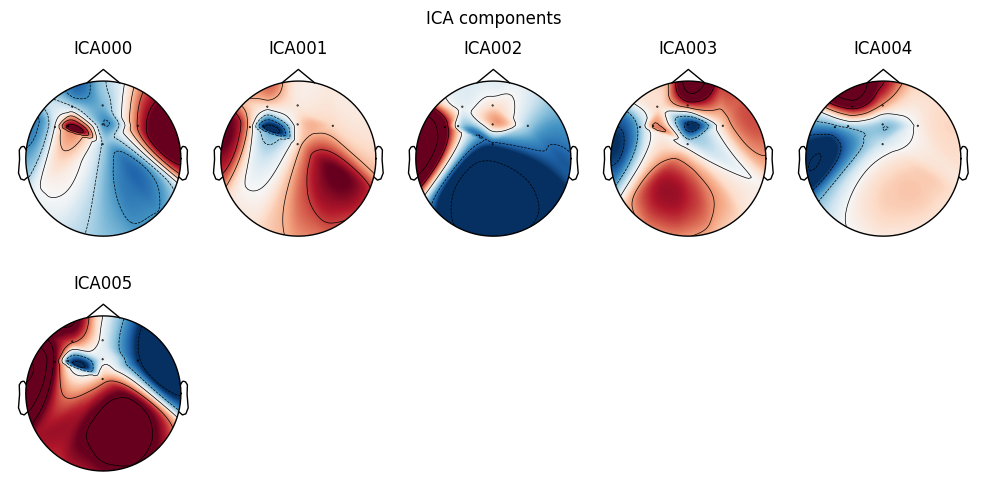

Creating RawArray with float64 data, n_channels=6, n_times=66760


    Range : 0 ... 66759 =      0.000 ...   267.036 secs


Ready.


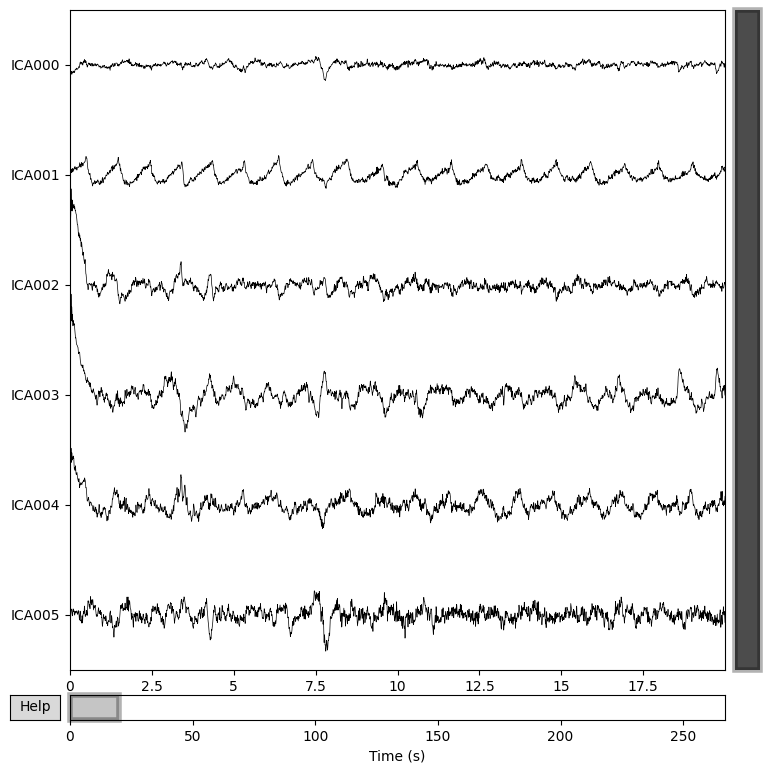

Applying ICA to Raw instance


    Transforming to ICA space (6 components)


    Zeroing out 0 ICA components


    Projecting back using 7 PCA components


In [69]:
import numpy as np
import pandas as pd
import mne
import matplotlib.pyplot as plt

# first_data: rows = samples, columns = 8 EEG channels
# 1. Clean and Load Data
full_eeg_df = eeg_raw.drop(columns=["Ch12", "Timestamp"])
df = pd.DataFrame(full_eeg_df.copy())
df = df.replace([np.inf, -np.inf], np.nan)
df = df.replace(-200000.0, np.nan)
threshold = len(df) * 0.5
df = df.dropna(thresh=threshold, axis=1)
df = df.interpolate(method='linear', limit=5, limit_direction='both')
df = df.fillna(method='bfill').fillna(method='ffill')

# 2. MNE Array Building
sfreq = 250
data = df.values.T  # shape: (n_channels, n_samples)

# Mapping
ch_names = [
    "Fz",   # 1
    "FC3",   # 2
    "FC5",  # 3
    "F3",   # 4
    "FC4",   # 5
    "FCz",  # 6
    "Cz",  # 7
    #"F5"    # 8
]

info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types='eeg')
raw = mne.io.RawArray(data, info)

# 3. ICA topography
montage = mne.channels.make_standard_montage("standard_1020")
raw.set_montage(montage)

# 4. Filtering
raw.filter(1., 40., fir_design='firwin')
raw.notch_filter(60.)
raw.set_eeg_reference('average')

# 5. ICA
ica = mne.preprocessing.ICA(
    n_components= 0.99999,
    random_state=97,
    max_iter='auto'
)
ica.fit(raw)

#plotting components
ica.plot_components()      # scalp maps
ica.plot_sources(raw)      # time series

ica.exclude = []  # don't know how to do this
raw_clean = ica.apply(raw.copy())



In [70]:
trial_ts

108    2.811706e+06
110    2.811718e+06
112    2.811803e+06
114    2.811831e+06
116    2.811846e+06
Name: Timestamp, dtype: float64

In [71]:
import numpy as np
import pandas as pd

# ---------------------------------------------------------------------------
# Match trial_ts (LSL timestamps) to closest sample index in eeg_raw
# ---------------------------------------------------------------------------
# Assumes:
#   - trial_ts: array-like of LSL timestamps to match (e.g. lifu_on, or any
#     other event-time array on the same LSL clock)
#   - eeg_raw:  DataFrame with a 'Timestamp' column (LSL time), same clock

timestamps = eeg_raw['Timestamp'].values
trial_ts = np.asarray(trial_ts)

# --- vectorized nearest-timestamp match ---
insert_idx = np.searchsorted(timestamps, trial_ts)
insert_idx = np.clip(insert_idx, 1, len(timestamps) - 1)

left_vals = timestamps[insert_idx - 1]
right_vals = timestamps[insert_idx]

use_left = np.abs(trial_ts - left_vals) < np.abs(trial_ts - right_vals)
matched_idx = np.where(use_left, insert_idx - 1, insert_idx)

# --- sanity check match quality ---
matched_time = timestamps[matched_idx]
time_diff = matched_time - trial_ts  # signed: negative = eeg sample before event, positive = after

fs = 1 / np.median(np.diff(timestamps))  # estimate actual sampling rate from data
expected_max_diff = 0.5 / fs  # half a sample period

n_bad = np.sum(np.abs(time_diff) > expected_max_diff)
if n_bad > 0:
    print(f"Warning: {n_bad} of {len(trial_ts)} matches exceed half a sample period "
          f"({expected_max_diff*1000:.2f} ms). Check for stream dropouts or clock offset.")
else:
    print(f"All {len(trial_ts)} matches within expected tolerance "
          f"({expected_max_diff*1000:.2f} ms), estimated fs = {fs:.2f} Hz.")

trial_index_df = pd.DataFrame({
    'trial_ts': trial_ts,
    'matched_index': matched_idx,
    'matched_timestamp': matched_time,
    'time_diff_sec': time_diff,
})
trial_index_df

All 5 matches within expected tolerance (2.00 ms), estimated fs = 249.98 Hz.


,trial_ts,matched_index,matched_timestamp,time_diff_sec
0,2.811706e+06,13920,2.811706e+06,-0.000525
1,2.811718e+06,17110,2.811718e+06,-0.001787
2,2.811803e+06,38241,2.811803e+06,0.001393
3,2.811831e+06,45220,2.811831e+06,-0.000073
4,2.811846e+06,49019,2.811846e+06,-0.000483


In [72]:
#event_samples = (lifu_on_time_onset * raw.info['sfreq']).astype(int)
event_samples = np.array(trial_index_df['matched_index'])

# Build MNE event array: shape (n_events, 3)
# Columns: [sample_index, 0, event_id]
events = np.column_stack([event_samples, 
                          np.zeros_like(event_samples, dtype=int), 
                          np.ones_like(event_samples, dtype=int)])
tmin = -5.0
tmax = 10.0

epochs = mne.Epochs(
    raw,
    events,
    event_id=1,
    tmin=tmin,
    tmax=tmax,
    baseline=(-0.2, 0),     # or (-2, 0) if you want baseline correction
    preload=True
)


Not setting metadata


5 matching events found


Applying baseline correction (mode: mean)


0 projection items activated


Using data from preloaded Raw for 5 events and 3751 original time points ...


0 bad epochs dropped


Number of frequencies: 129


Number of time steps: 59


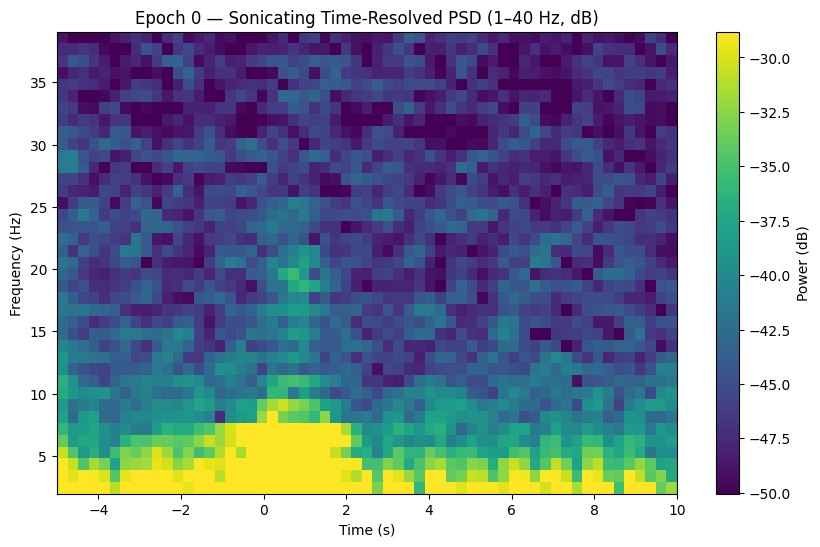

Number of frequencies: 129


Number of time steps: 59


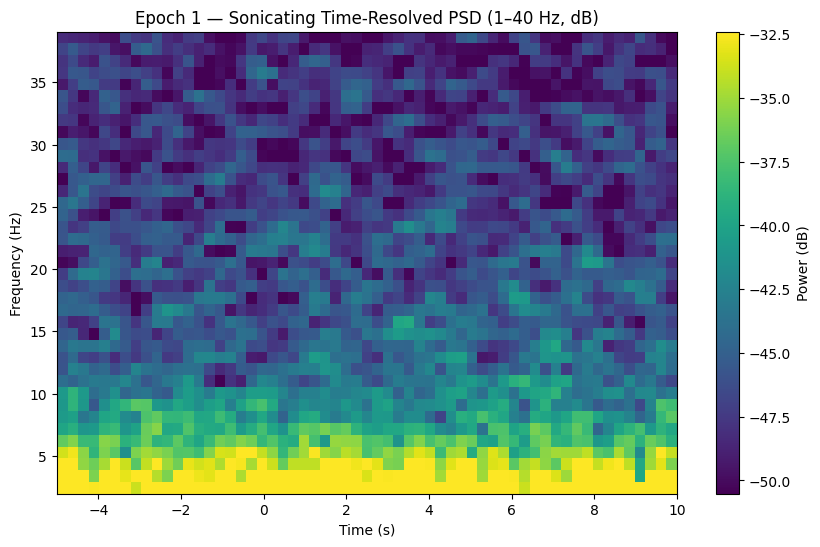

Number of frequencies: 129


Number of time steps: 59


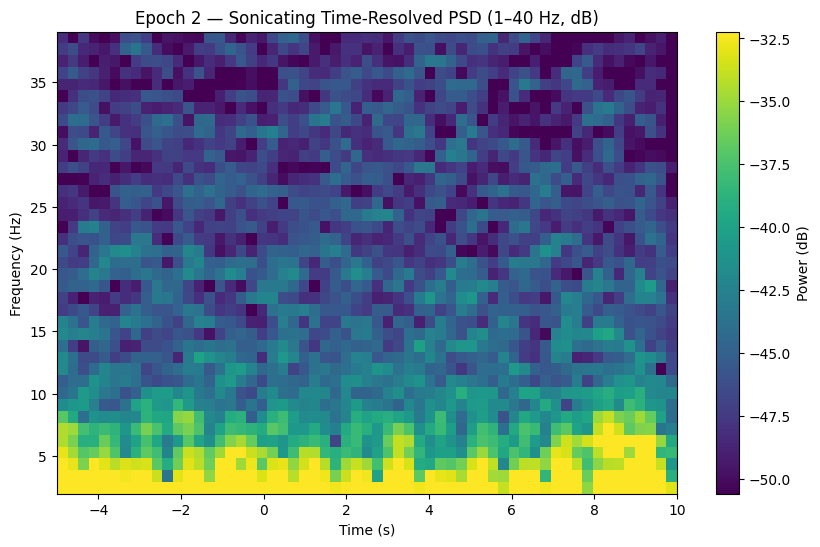

Number of frequencies: 129


Number of time steps: 59


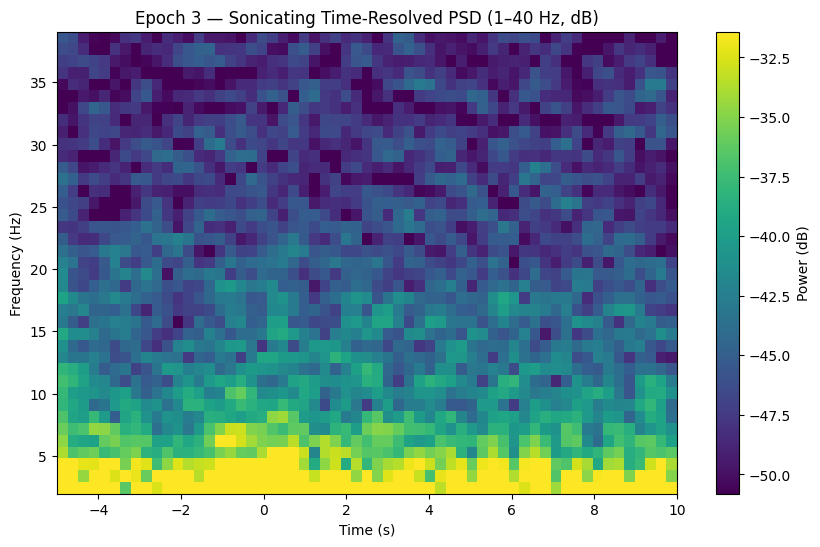

Number of frequencies: 129


Number of time steps: 59


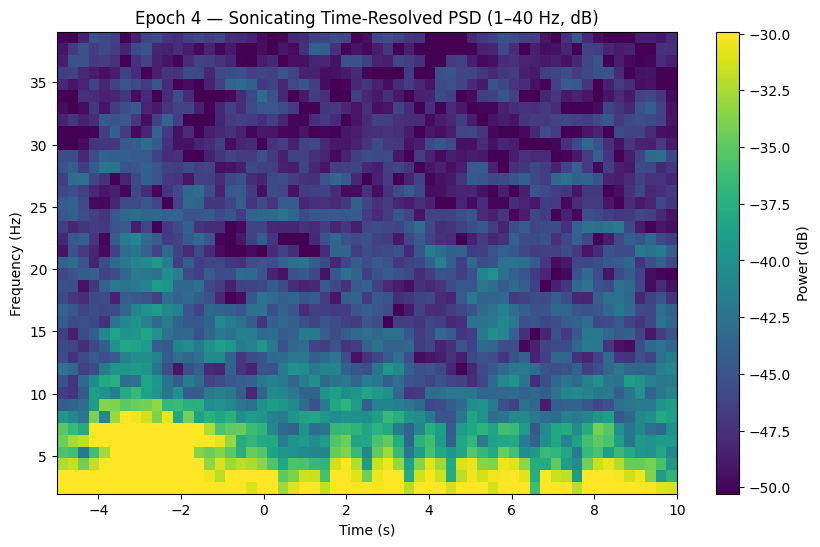

In [73]:
from mne.time_frequency import stft
import numpy as np
import matplotlib.pyplot as plt

sfreq = epochs.info['sfreq']
ch_names = epochs.ch_names

all_spectrograms = []
all_times = []
all_freqs = []

# Loop over epochs
for idx, ep in enumerate(epochs):
    data = ep #* 1e-6   # µV → V
    n_fft = 256
    step = 64

    # stft
    Zxx = stft(data, wsize=n_fft, tstep=step)
    power = np.abs(Zxx)**2 / (n_fft**2) # normalizing

    # time axis
    tmin = epochs.tmin
    tmax = epochs.tmax
    times = np.linspace(tmin, tmax, power.shape[-1])
    # freq axis
    freqs = np.linspace(0, sfreq/2, power.shape[1])

    # frequencies you want to see (1-40Hz)
    mask = (freqs >= 1) & (freqs <= 40)
    freqs_1_40 = freqs[mask]
    power_1_40 = power[:, mask, :]

    # single graph for each epoch (averaging across channels)
    psd_avg = power_1_40.mean(axis=0)

    # convert to db for better visualizations
    psd_db = 10 * np.log10(psd_avg + 1e-20)

    # only use 95%
    vmin = np.percentile(psd_db, 5)
    vmax = np.percentile(psd_db, 95)
    
    all_spectrograms.append(psd_db)
    all_times.append(times)
    all_freqs.append(freqs_1_40)

    # --- Plot ---
    plt.figure(figsize=(10,6))
    plt.imshow(
        psd_db,
        aspect='auto',
        origin='lower',
        extent=[times[0], times[-1], freqs_1_40[0], freqs_1_40[-1]],
        vmin=vmin,
        vmax=vmax,
        cmap='viridis'
    )
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Hz)")
    plt.title(f"Epoch {idx} — Sonicating Time‑Resolved PSD (1–40 Hz, dB)")
    plt.colorbar(label="Power (dB)")
    plt.show()


Effective window size : 0.512 (s)


Effective window size : 0.512 (s)


Plotting power spectral density (dB=True).


Averaging across epochs before plotting...


Plotting power spectral density (dB=True).


Averaging across epochs before plotting...


C:\Users\jshin\AppData\Local\Programs\Python\Python310\lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)
C:\Users\jshin\AppData\Local\Programs\Python\Python310\lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


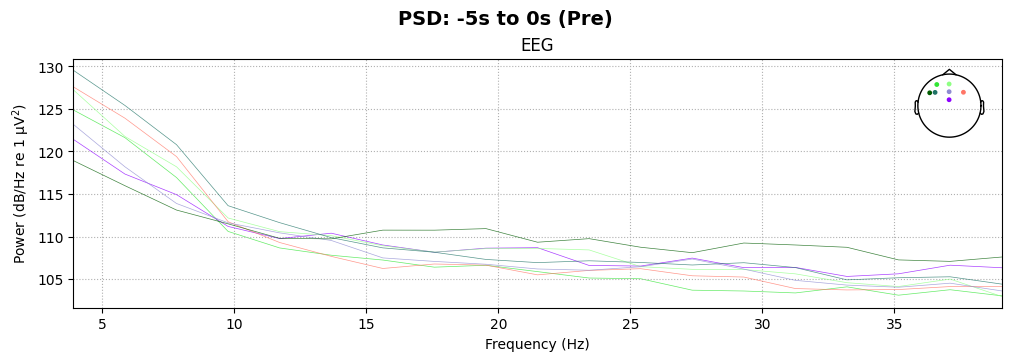

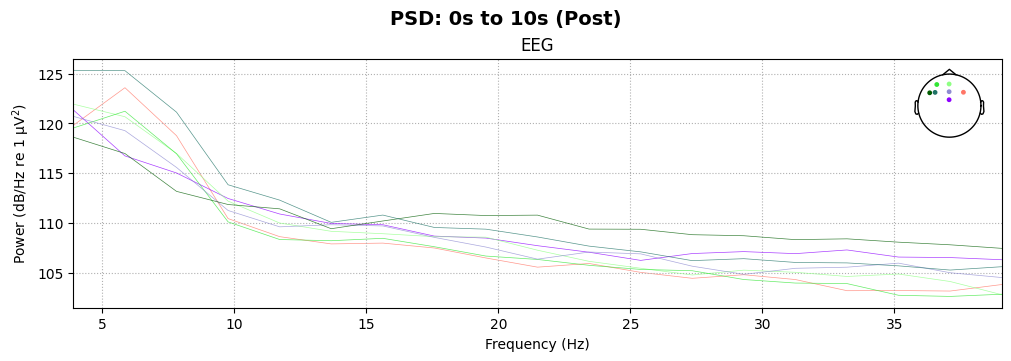

NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.


Applying baseline correction (mode: logratio)


[Parallel(n_jobs=-1)]: Done   2 out of   7 | elapsed:    4.3s remaining:   10.9s
[Parallel(n_jobs=-1)]: Done   4 out of   7 | elapsed:    4.3s remaining:    3.2s
[Parallel(n_jobs=-1)]: Done   7 out of   7 | elapsed:    4.3s finished
C:\Users\jshin\AppData\Local\Temp\ipykernel_23224\1715033836.py:46: RuntimeWarning: tmax is not in time interval. tmax is set to <class 'mne.time_frequency.tfr.AverageTFR'>.tmax (10 s)
  power.crop(tmin=-4, tmax=49)


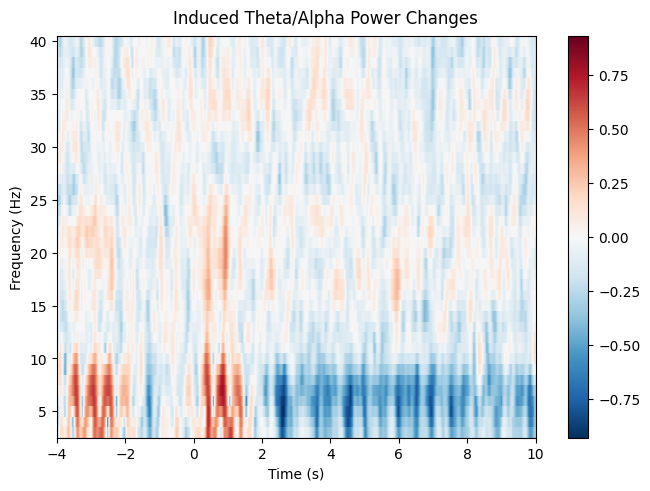

[<Figure size 640x480 with 2 Axes>]

In [74]:

import matplotlib.pyplot as plt

# Window 1: -6s to -1s (e.g., pre-sonication baseline)
epochs_pre = epochs.copy().crop(tmin=-5, tmax=0)
spectrum_pre = epochs_pre.compute_psd(method="welch", fmin=2, fmax=40, n_fft=128)

# Window 2: 5s to 10s (e.g., post-sonication)
epochs_post = epochs.copy().crop(tmin=0, tmax=10)
spectrum_post = epochs_post.compute_psd(method="welch", fmin=2, fmax=40, n_fft=128)

# Plot both
fig_pre = spectrum_pre.plot(picks='all', spatial_colors=True, exclude='bads')
fig_pre.suptitle('PSD: -5s to 0s (Pre)', fontsize=14, weight='bold')

fig_post = spectrum_post.plot(picks='all', spatial_colors=True, exclude='bads')
fig_post.suptitle('PSD: 0s to 10s (Post)', fontsize=14, weight='bold')

plt.show()

import numpy as np
import matplotlib.pyplot as plt
from mne.time_frequency import tfr_morlet

# 1. Define frequencies of interest (log spacing is ideal for wavelets)
freqs = np.linspace(3.0, 40.0, num=38) 

# 2. Define number of cycles per frequency 
# For theta, a lower number (e.g., 3-4) gives better time resolution, 
# while a fixed number or slightly increasing scales with frequency.
n_cycles = freqs / 2.0  # Dynamic cycles balance time/frequency trade-offs

# 3. Compute Time-Frequency Representation (TFR)
# This returns an AverageTFR object containing induced power
power = tfr_morlet(
    epochs, 
    freqs=freqs, 
    n_cycles=n_cycles, 
    use_fft=True, 
    return_itc=False,  # Set to True if you also want Inter-Trial Coherence
    n_jobs=-1          # Use all CPU cores
)

# 4. Plot with Baseline Correction (Crucial step!)
# Assuming your baseline is from -0.5 to 0 seconds before stimulus onset
baseline_interval = (-2, 0)
power.crop(tmin=-4, tmax=49)

# Mode 'logratio' or 'percent' reveals the actual task-induced changes
power.plot(
    picks='data',           # Averages across the channels picked
    baseline=baseline_interval, 
    mode='logratio',        # Options: 'logratio' (dB), 'percent', 'zscore'
    title="Induced Theta/Alpha Power Changes",
    combine='mean'          # Automatically averages across your channels
)


Effective window size : 2.048 (s)


Plotting power spectral density (dB=True).


Averaging across epochs before plotting...


C:\Users\jshin\AppData\Local\Programs\Python\Python310\lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


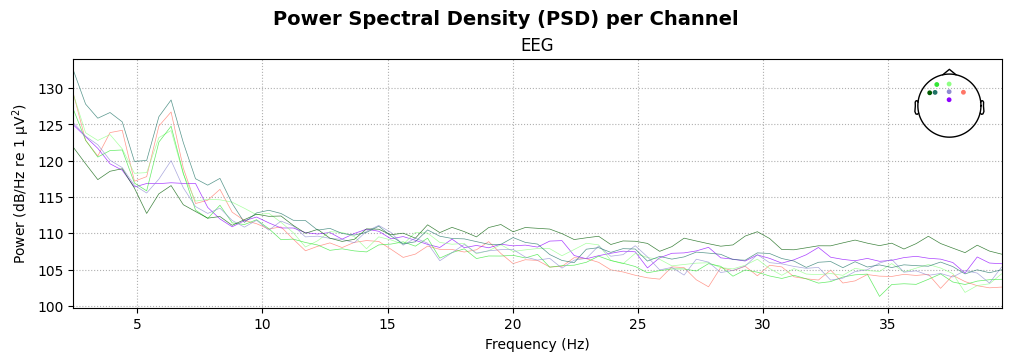

In [75]:
# averages all epochs for PSD

spectrum = epochs.compute_psd(method= "welch",fmin=2, fmax=40, n_fft=512)

# Plot the spectrum across all channels
fig = spectrum.plot(picks='all', spatial_colors=True, exclude='bads')

# Adjust the plot title and layout
fig.suptitle('Power Spectral Density (PSD) per Channel', fontsize=14, weight='bold')
plt.show()


In [76]:
base_dir_raw = r"C:\Users\jshin\OW_closedloopLIFU\eeg_windows\raw"
# MAKE SURE TO PUT IN NAME
new_folder_name = "active"
new_folder_path_raw = os.path.join(base_dir_raw, new_folder_name)
os.makedirs(new_folder_path_raw, exist_ok=False) # check

for idx, event in enumerate(raw_windows):
    # Build a unique filename for each event
    output_path_raw = os.path.join(new_folder_path_raw, f"{idx}_eeg_cleaned.csv")
    try:
        raw_windows[idx].to_csv(output_path_raw, index=False, encoding="utf-8")
        print(f"Saved successfully to: {output_path_raw}")
    except (OSError, IOError) as e:
        print(f"Error saving CSV file: {e}")

FileExistsError: [WinError 183] Cannot create a file when that file already exists: 'C:\\Users\\jshin\\OW_closedloopLIFU\\eeg_windows\\raw\\active'

In [77]:
epochs.get_data().shape

(5, 7, 3751)

In [78]:
# PSD DATA ANALYSIS
# Part 1: percent change pre and post trigger (averaged across ALL trials, not just trial 0)

fs = 250
prev = 5
pre_window = int(prev * fs)
# epochs run tmin=-5 to tmax=10 (15s total), so "post" is the remaining ~10s after t=0

n_epochs = epochs.get_data().shape[0]
pre_segments = []
post_segments = []
for i in range(n_epochs):
    eeg_filt = pd.DataFrame(epochs.get_data()[i].copy()).T  # time x channels for trial i
    pre_segments.append(eeg_filt.iloc[:pre_window])
    post_segments.append(eeg_filt.iloc[pre_window:])

In [79]:
from scipy.signal import welch
import numpy as np

def compute_psd(seg):
    f, psd = welch(seg, fs=fs, nperseg=fs, axis=0)
    return f, psd  # psd shape: freqs × channels
pre_psds  = []
post_psds = []

for pre, post in zip(pre_segments, post_segments):
    f, pre_psd  = compute_psd(pre)
    f, post_psd = compute_psd(post)
    pre_psds.append(pre_psd)
    post_psds.append(post_psd)
pre_psd_mean  = np.mean(pre_psds, axis=0)
post_psd_mean = np.mean(post_psds, axis=0)


In [80]:
percent_change_psd = (post_psd_mean - pre_psd_mean) / pre_psd_mean * 100
percent_change_psd = pd.DataFrame(percent_change_psd)

# dB (log-ratio) version -- same scaling as the STFT/Morlet plots above.
# Much less sensitive to a noisy/small pre-window denominator than a raw percent change.
db_change_psd = 10 * np.log10(post_psd_mean / pre_psd_mean)
db_change_psd = pd.DataFrame(db_change_psd)

percent_change_psd

,0,1,2,3,4,5,6
0,18.880732,33.100465,29.997398,87.795317,-45.345752,88.162102,-5.834326
1,-28.924524,25.133219,-16.225788,17.516548,-54.551393,8.484243,15.066962
2,-51.781587,-20.241258,-25.125740,-38.273174,-67.407725,-22.075842,14.646086
3,-21.385049,15.300765,2.013705,-3.849274,-9.039216,-2.428642,21.578512
4,-45.163790,-36.392962,8.280280,-44.448323,-34.773626,-0.366464,-11.040965
...,...,...,...,...,...,...,...
121,18.230224,13.963847,13.077523,10.104405,13.690149,13.897640,12.411788
122,12.080674,5.912755,-10.031638,-6.025822,14.027766,22.724538,-30.944200
123,-5.577012,-17.821878,33.456674,2.280881,10.333242,21.951315,-25.538479
124,26.373992,24.916028,35.207385,30.951104,18.621065,88.110426,-19.148229


In [81]:
from IPython.display import display

def band_power(psd, freqs, f_lo, f_hi):
    idx = (freqs >= f_lo) & (freqs <= f_hi)
    return np.trapezoid(psd[idx, :], freqs[idx], axis=0)

bands = {"Theta": (4, 7), "Alpha": (8, 12), "Beta": (13, 30), "Gamma": (30, 40)}
ch_index = [f"Ch{i+1}" for i in range(7)]

# per-trial band power/percent-change/dB-change (pre_psds/post_psds hold one PSD per trial)
trial_pct = {name: [] for name in bands}
trial_db = {name: [] for name in bands}
for pre_psd, post_psd in zip(pre_psds, post_psds):
    for name, (lo, hi) in bands.items():
        pre_bp = band_power(pre_psd, f, lo, hi)
        post_bp = band_power(post_psd, f, lo, hi)
        trial_pct[name].append((post_bp - pre_bp) / pre_bp * 100)
        trial_db[name].append(10 * np.log10(post_bp / pre_bp))

# mean across trials -- this replaces the old single-trial percent change
bands_pct_df = pd.DataFrame({f"{name} %Δ": np.mean(trial_pct[name], axis=0) for name in bands}, index=ch_index)

# std across trials -- large values here mean the mean is being driven by one outlier
# trial rather than a consistent effect, which is exactly what happened before this fix
bands_pct_std_df = pd.DataFrame({f"{name} %Δ (trial std)": np.std(trial_pct[name], axis=0) for name in bands}, index=ch_index)

# dB change -- same log scaling as the STFT/Morlet plots, much less sensitive to a
# noisy/small pre-window denominator than the raw percent change above
bands_db_df = pd.DataFrame({f"{name} ΔdB": np.mean(trial_db[name], axis=0) for name in bands}, index=ch_index)

print("Percent change in band power (mean across all trials):")
display(bands_pct_df)

print("\nStd of percent change across trials (large = unreliable / outlier-driven):")
display(bands_pct_std_df)

print("\ndB change in band power (log-ratio, comparable to STFT/Morlet):")
display(bands_db_df)

Percent change in band power (mean across all trials):


,Theta %Δ,Alpha %Δ,Beta %Δ,Gamma %Δ
Ch1,-3.374729,-9.465857,-13.698707,4.550301
Ch2,43.060743,18.743614,14.081012,6.913105
Ch3,10.057754,-1.016479,-7.404891,-4.576361
Ch4,11.726612,-17.572995,12.889819,0.929997
Ch5,41.559818,-14.771962,-0.143286,-9.458354
Ch6,20.026761,-10.822132,19.837351,16.692499
Ch7,-10.431534,6.553715,-2.560357,3.697703



Std of percent change across trials (large = unreliable / outlier-driven):


,Theta %Δ (trial std),Alpha %Δ (trial std),Beta %Δ (trial std),Gamma %Δ (trial std)
Ch1,66.706950,13.432579,8.696846,13.468963
Ch2,135.556831,65.973535,35.181142,14.186662
Ch3,47.133889,18.232487,11.364238,9.027407
Ch4,76.688890,31.515900,19.740183,12.764254
Ch5,122.549106,40.626408,33.248225,6.822600
Ch6,92.544864,19.194491,21.548208,11.538196
Ch7,23.384650,23.357077,16.573145,7.699564



dB change in band power (log-ratio, comparable to STFT/Morlet):


,Theta ΔdB,Alpha ΔdB,Beta ΔdB,Gamma ΔdB
Ch1,-2.406480,-0.477934,-0.662060,0.157918
Ch2,-1.925203,-0.401313,0.316151,0.249146
Ch3,-0.298436,-0.119244,-0.366649,-0.222824
Ch4,-2.320771,-1.270886,0.458724,0.000421
Ch5,-2.479475,-1.544841,-0.365114,-0.444215
Ch6,-1.021646,-0.606727,0.707961,0.650406
Ch7,-0.681817,0.162512,-0.174569,0.144865


In [82]:
event_samples

array([13920, 17110, 38241, 45220, 49019])

In [83]:
ns_array = np.array([150,200]) 
not_sonicating_array = (ns_array * raw.info['sfreq']).astype(int)
not_sonicating_events = np.column_stack([not_sonicating_array, 
                          np.zeros_like(event_samples, dtype=int), 
                          np.ones_like(event_samples, dtype=int)])

epochs_ns = mne.Epochs(
    raw,
    not_sonicating_events,
    event_id=1,
    tmin=tmin,
    tmax=tmax,
    baseline=(-2, 0),     # or (-2, 0) if you want baseline correction
    preload=True
)


ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 0, the array at index 0 has size 2 and the array at index 1 has size 5

In [84]:
from mne.time_frequency import stft
import numpy as np
import matplotlib.pyplot as plt

sfreq = epochs_ns.info['sfreq']
ch_names = epochs_ns.ch_names

all_spectrograms = []
all_times = []
all_freqs = []

# Loop over epochs
for idx, ep in enumerate(epochs_ns):

    # ep shape: (n_channels, n_times)
    data = ep #* 1e-6   # dont convert from microvolts to volts
    n_fft = 256
    step = 64

    # COMPUTE STFT
    Zxx = stft(data, wsize=n_fft, tstep=step)
    power = np.abs(Zxx)**2 / (n_fft**2)

    # time axis
    tmin = epochs.tmin
    tmax = epochs.tmax
    times = np.linspace(tmin, tmax, power.shape[-1])
    # frequency axis
    freqs = np.linspace(0, sfreq/2, power.shape[1])

    # frequency mask
    mask = (freqs >= 1) & (freqs <= 40)
    freqs_1_40 = freqs[mask]
    power_1_40 = power[:, mask, :]

    # --- Average across channels ---
    psd_avg = power_1_40.mean(axis=0)

    # db conversion
    psd_db = 10 * np.log10(psd_avg + 1e-20)

    # keeping scaling proper - exclude 5 % each
    vmin = np.percentile(psd_db, 5)
    vmax = np.percentile(psd_db, 95)

    all_spectrograms.append(psd_db)
    all_times.append(times)
    all_freqs.append(freqs_1_40)

    # --- Plot ---
    plt.figure(figsize=(10,6))
    plt.imshow(
        psd_db,
        aspect='auto',
        origin='lower',
        extent=[times[0], times[-1], freqs_1_40[0], freqs_1_40[-1]],
        vmin=vmin,
        vmax=vmax,
        cmap='viridis'
    )
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Hz)")
    plt.title(f"Epoch {idx} —  Not Sonicating Time‑Resolved PSD (1–40 Hz, dB)")
    plt.colorbar(label="Power (dB)")
    plt.show()


NameError: name 'epochs_ns' is not defined

In [85]:

import matplotlib.pyplot as plt

# Window 1: -6s to -1s (e.g., pre-sonication baseline)
epochs_pre = epochs_ns.copy().crop(tmin=-5, tmax=0)
spectrum_pre = epochs_pre.compute_psd(method="welch", fmin=2, fmax=40, n_fft=128)

# Window 2: 5s to 10s (e.g., post-sonication)
epochs_post = epochs_ns.copy().crop(tmin=0, tmax=10)
spectrum_post = epochs_post.compute_psd(method="welch", fmin=2, fmax=40, n_fft=128)

# Plot both
fig_pre = spectrum_pre.plot(picks='all', spatial_colors=True, exclude='bads')
fig_pre.suptitle('PSD: -5s to 0s (Pre)', fontsize=14, weight='bold')

fig_post = spectrum_post.plot(picks='all', spatial_colors=True, exclude='bads')
fig_post.suptitle('PSD: 0s to 10s (Post)', fontsize=14, weight='bold')

plt.show()

import numpy as np
import matplotlib.pyplot as plt
from mne.time_frequency import tfr_morlet

# 1. Define frequencies of interest (log spacing is ideal for wavelets)
freqs = np.linspace(3.0, 40.0, num=38) 

# 2. Define number of cycles per frequency 
# For theta, a lower number (e.g., 3-4) gives better time resolution, 
# while a fixed number or slightly increasing scales with frequency.
n_cycles = freqs / 2.0  # Dynamic cycles balance time/frequency trade-offs

# 3. Compute Time-Frequency Representation (TFR)
# This returns an AverageTFR object containing induced power
power = tfr_morlet(
    epochs_ns, 
    freqs=freqs, 
    n_cycles=n_cycles, 
    use_fft=True, 
    return_itc=False,  # Set to True if you also want Inter-Trial Coherence
    n_jobs=-1          # Use all CPU cores
)

# 4. Plot with Baseline Correction (Crucial step!)
# Assuming your baseline is from -0.5 to 0 seconds before stimulus onset
baseline_interval = (-2, 0)
power.crop(tmin=-4, tmax=49)

# Mode 'logratio' or 'percent' reveals the actual task-induced changes
power.plot(
    picks='data',           # Averages across the channels picked
    baseline=baseline_interval, 
    mode='logratio',        # Options: 'logratio' (dB), 'percent', 'zscore'
    title="Induced Theta/Alpha Power Changes",
    combine='mean'          # Automatically averages across your channels
)


NameError: name 'epochs_ns' is not defined